In [1]:
from google.colab import files
uploaded = files.upload()

Saving Fake.csv to Fake.csv
Saving True.csv to True.csv


In [2]:
import pandas as pd
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def main():
    print("Loading raw datasets into Colab (Skipping bad lines)...")
    # on_bad_lines='skip' ensures it ignores any broken rows without crashing
    fake_df = pd.read_csv('Fake.csv', on_bad_lines='skip', engine='python')
    true_df = pd.read_csv('True.csv', on_bad_lines='skip', engine='python')

    true_df['label'] = 1
    fake_df['label'] = 0

    print("Merging datasets...")
    combined_df = pd.concat([true_df, fake_df], ignore_index=True)

    print("Cleaning text data... (This may take a minute or two)")
    combined_df['cleaned_text'] = combined_df['text'].apply(clean_text)

    output_path = 'cleaned_news_dataset.csv'
    combined_df.to_csv(output_path, index=False)

    print(f"Success! Cleaned dataset saved as: {output_path}")

main()

Loading raw datasets into Colab (Skipping bad lines)...
Merging datasets...
Cleaning text data... (This may take a minute or two)
Success! Cleaned dataset saved as: cleaned_news_dataset.csv


Load and Split the Clean Data

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

print("Loading clean dataset for training...")
# Loading directly from Colab's main folder
df = pd.read_csv('cleaned_news_dataset.csv')

# Drop any rows where the cleaning process left empty strings
df = df.dropna(subset=['cleaned_text'])

# Define X (Features) and y (Target)
X = df['cleaned_text']
y = df['label']

# Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Loading clean dataset for training...
Training samples: 35346
Testing samples: 8837


Train and Evaluate the Naive Bayes Model

1. Vectorizing text using TF-IDF...
2. Training Multinomial Naive Bayes model...
3. Generating Evaluation Metrics...

--- Naive Bayes Evaluation ---
Accuracy:  0.9444

Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

    Fake (0)       0.95      0.94      0.95      4516
    Real (1)       0.94      0.94      0.94      4321

    accuracy                           0.94      8837
   macro avg       0.94      0.94      0.94      8837
weighted avg       0.94      0.94      0.94      8837



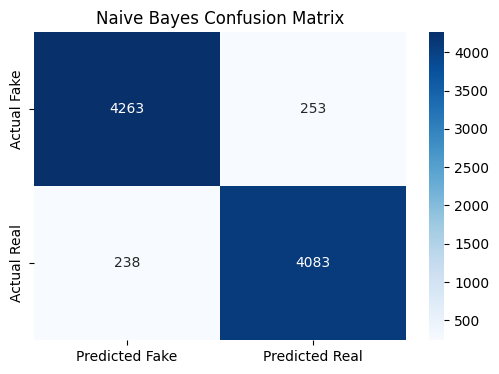

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("1. Vectorizing text using TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("2. Training Multinomial Naive Bayes model...")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

print("3. Generating Evaluation Metrics...\n")
y_pred = nb_model.predict(X_test_tfidf)

print("--- Naive Bayes Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)']))

# Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fake', 'Predicted Real'],
            yticklabels=['Actual Fake', 'Actual Real'])
plt.title('Naive Bayes Confusion Matrix')
plt.show()

Tokenization & Padding (Deep Learning Preprocessing)

In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

print("1. Tokenizing and Padding text for Deep Learning...")

# Configuration parameters
MAX_WORDS = 10000     # Maximum vocabulary size
MAX_LEN = 300         # Maximum length of each news article sequence

# Initialize and fit the Tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X_train)

# Convert text into integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad the sequences so every article is exactly 300 'words' long
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')

# Convert labels to numpy arrays (required by TensorFlow)
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)

print(f"Padded Training Data Shape: {X_train_pad.shape}")

1. Tokenizing and Padding text for Deep Learning...
Padded Training Data Shape: (35346, 300)


Build and Train the TextCNN

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

print("2. Building TextCNN Architecture...")

# Build the Sequential Model
model = Sequential([
    # Embedding layer: Creates dense vector representations of the words
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),

    # Convolutional Layer: Extracts n-gram features (reading 5 words at a time)
    Conv1D(filters=128, kernel_size=5, activation='relu'),

    # Pooling Layer: Downsamples to find the most important features
    GlobalMaxPooling1D(),

    # Fully Connected Dense Layer with Dropout to prevent overfitting
    Dense(64, activation='relu'),
    Dropout(0.5),

    # Final Output Layer (Sigmoid for binary classification: 0 or 1)
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

print("\n3. Training the TextCNN Model...")
# Train the model for 5 epochs
history = model.fit(
    X_train_pad, y_train_np,
    epochs=5,
    batch_size=64,
    validation_data=(X_test_pad, y_test_np)
)

2. Building TextCNN Architecture...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


3. Training the TextCNN Model...
Epoch 1/5
553/553 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9510 - loss: 0.1171 - val_accuracy: 0.9908 - val_loss: 0.0288
Epoch 2/5
553/553 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9964 - loss: 0.0134 - val_accuracy: 0.9960 - val_loss: 0.0137
Epoch 3/5
553/553 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.9919 - val_loss: 0.0286
Epoch 4/5
553/553 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 1.0000 - loss: 4.0627e-04 - val_accuracy: 0.9962 - val_loss: 0.0177
Epoch 5/5
553/553 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 1.0000 - loss: 1.8365e-04 - val_accuracy: 0.9956 - val_loss: 0.0189


Evaluate the TextCNN

4. Generating TextCNN Evaluation Metrics...

277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
--- TextCNN Evaluation ---
Accuracy:  0.9956

Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

    Fake (0)       1.00      1.00      1.00      4516
    Real (1)       1.00      1.00      1.00      4321

    accuracy                           1.00      8837
   macro avg       1.00      1.00      1.00      8837
weighted avg       1.00      1.00      1.00      8837



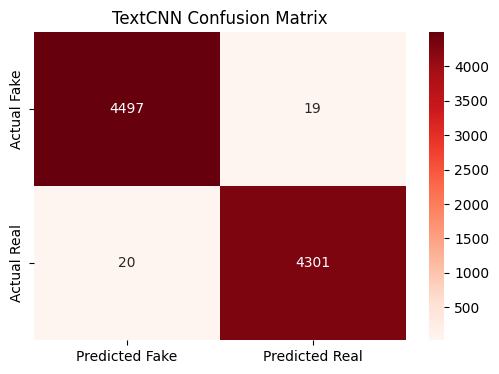

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("4. Generating TextCNN Evaluation Metrics...\n")

# Get model predictions (outputs probabilities between 0 and 1)
y_pred_probs = model.predict(X_test_pad)

# Convert probabilities to definitive binary classes (0 or 1)
y_pred_dl = (y_pred_probs > 0.5).astype(int)

# Print standard metrics
print("--- TextCNN Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test_np, y_pred_dl):.4f}")
print("\nClassification Report (Precision, Recall, F1-Score):")
print(classification_report(y_test_np, y_pred_dl, target_names=['Fake (0)', 'Real (1)']))

# Plot the Confusion Matrix
cm_dl = confusion_matrix(y_test_np, y_pred_dl)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Fake', 'Predicted Real'],
            yticklabels=['Actual Fake', 'Actual Real'])
plt.title('TextCNN Confusion Matrix')
plt.show()

In [8]:
# Save the deep learning model as an H5 file
model.save('truthguard_textcnn.h5')
print("Model saved successfully!")

Model saved successfully!


In [9]:
import pickle

# 1. Save your 99.5% accurate TextCNN model
model.save('truthguard_textcnn.h5')

# 2. Save the tokenizer so the web app can process new text
with open('tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("Export complete! Download truthguard_textcnn.h5 and tokenizer.pkl")

Export complete! Download truthguard_textcnn.h5 and tokenizer.pkl


In [10]:
import joblib

# Replace 'nb_model' with whatever variable name you used for your Naive Bayes model!
# (For example, it might just be 'model' or 'clf')
joblib.dump(nb_model, 'naive_bayes_model.pkl')

print("Naive Bayes model exported successfully!")

Naive Bayes model exported successfully!
